Loading model and generating embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


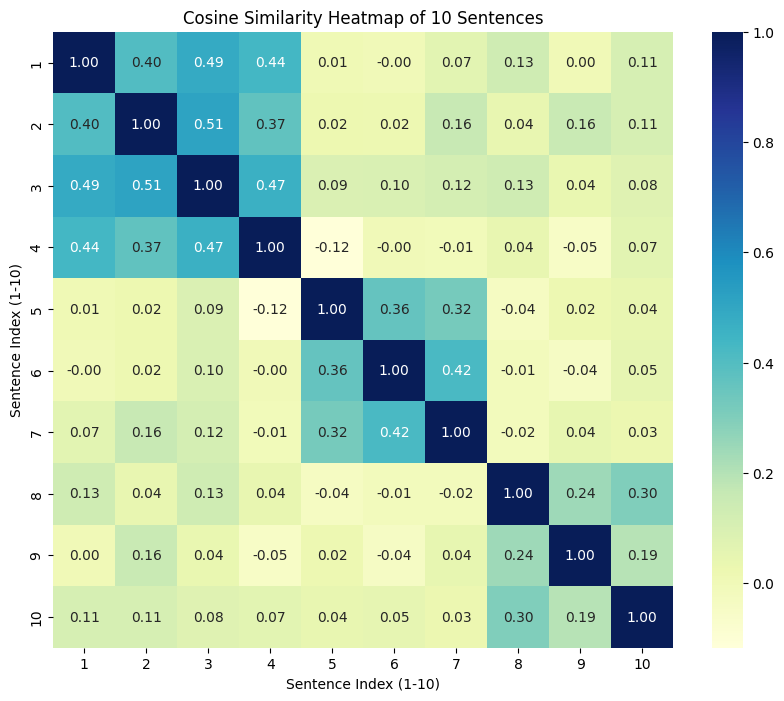


Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
- [3] 'The spin bowler managed to get immense turn on the pitch.' (Similarity Score: 0.6511)
- [1] 'The batsman hit a massive six over the boundary line.' (Similarity Score: 0.5295)


In [2]:

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Write 10 sentences across exactly 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Topic 1: Cricket
    "The batsman hit a massive six over the boundary line.",
    "Fast bowlers rely on swing and pace to deceive the opening batter.",
    "The spin bowler managed to get immense turn on the pitch.",
    "The umpire signaled a wide ball after it went down the leg side.",

    # Topic 2: Cooking
    "To make the perfect pasta, boil the noodles until they are al dente.",
    "Simmer the tomato sauce with garlic, basil, and a pinch of salt.",
    "A sharp chef's knife is essential for finely dicing the onions and celery.",

    # Topic 3: Cybersecurity
    "The company suffered a massive data breach due to a sophisticated phishing attack.",
    "Implementing two-factor authentication greatly improves your overall account security.",
    "The security analyst patched the zero-day vulnerability in the network firewall."
]

# 2. Generate embeddings using sentence-transformers (all-MiniLM-L6-v2)
print("Loading model and generating embeddings...")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 3. Compute and display a 10x10 cosine similarity matrix as a heatmap
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu", fmt=".2f",
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("Cosine Similarity Heatmap of 10 Sentences")
plt.xlabel("Sentence Index (1-10)")
plt.ylabel("Sentence Index (1-10)")
plt.show()

# 4. Process new query and find top 2 similar sentences
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Calculate similarities between the query and our 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get the indices of the top 2 highest similarity scores
top_2_indices = np.argsort(query_similarities)[-2:][::-1]

print(f"\nQuery: '{query}'\n")
print("Top 2 most similar sentences:")
for idx in top_2_indices:
    print(f"- [{idx+1}] '{sentences[idx]}' (Similarity Score: {query_similarities[idx]:.4f})")